# AI/ML with Phage-Host Data: From DataFrames to Streaming

This notebook demonstrates how to use the PBI package for machine learning workflows — from simple DataFrame-based approaches to memory-efficient streaming for large-scale training.

## What You'll Learn

### Part 1: DataFrame Approach
1. Query phage-host pairs into a DataFrame
2. Exploratory data analysis with visualizations
3. Feature engineering from genomic properties
4. Generate negative examples (NegativeExampleGenerator)
5. Create a balanced dataset
6. Train a baseline Random Forest classifier

### Part 2: Streaming Datasets for Large-Scale ML
7. Why streaming matters (memory efficiency)
8. PhageHostStreamingDataset — sequential processing
9. PhageHostIndexedDataset — shuffled access
10. Simple batch iterator (non-PyTorch)
11. Custom transforms for preprocessing
12. Train/Test split strategy
13. Tracking missing sequences

## Why This Matters for Phage-Host Prediction

Predicting which phages can infect which bacteria has major applications:
- **Phage therapy**: Selecting phages to treat antibiotic-resistant infections
- **Microbiome research**: Understanding viral-bacterial dynamics
- **Biosecurity**: Predicting phage host ranges for safety assessment
- **Ecology**: Modeling phage-bacterial coevolution

The database provides thousands of experimentally validated phage-host pairs as **positive examples**. For ML classification, we also need **negative examples** (non-interacting pairs) — which PBI generates automatically.

## Setup & Imports

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PBI package
import pbi
from pbi import quick_connect, SequenceRetriever, NegativeExampleGenerator
from pbi import PhageHostStreamingDataset, PhageHostIndexedDataset, phage_host_collate_fn

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# Try to import PyTorch (optional)
try:
    import torch
    from torch.utils.data import DataLoader
    TORCH_AVAILABLE = True
    print("PyTorch available")
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not available - some examples will be skipped")

# Display settings
pd.set_option('display.max_columns', 50)
snx = sns.set_style('whitegrid')

print("All imports successful")
print(f"PBI version: {pbi.__version__ if hasattr(pbi, '__version__') else 'dev'}")

PyTorch available
All imports successful
PBI version: 0.1.0


## Database Connection

In [2]:
# Connect to database
retriever = quick_connect()

# Get database statistics
stats = retriever.get_stats()

print("Database Statistics:")
print(f"  Phages in DB: {stats['database']['phages']:,}")
print(f"  Proteins in DB: {stats['database']['proteins']:,}")
print(f"  Hosts in DB: {stats['database']['hosts']:,}")
print(f"  Phage-Host Associations: {stats['database']['phage_host_associations']:,}")
print()
print(f"  Phage sequences: {stats['fasta']['phages']:,}")
print(f"  Protein sequences: {stats['fasta']['proteins']:,}")
if 'hosts' in stats['fasta']:
    print(f"  Host sequences: {stats['fasta']['hosts']:,}")

2026-02-24 18:04:52,012 - INFO - 📂 Checking FASTA index files:
2026-02-24 18:04:52,013 - INFO -    Phage index: True (52570.4 KB)
2026-02-24 18:04:52,014 - INFO -    Protein index: True (1432185.2 KB)
2026-02-24 18:04:52,015 - INFO - 📂 Using host mapping file: /data/processed/sequences/host_fasta_mapping.json
2026-02-24 18:04:52,021 - INFO -    Loaded mapping for 5525 hosts
2026-02-24 18:04:52,021 - INFO - 📂 Connecting to database: /data/processed/databases/phage_database_optimized.duckdb
2026-02-24 18:04:52,056 - INFO - 🔄 Starting background FASTA loading...
2026-02-24 18:04:52,057 - INFO - 🔄 [Background] Loading phage FASTA: /data/processed/sequences/all_phages.fasta
2026-02-24 18:04:52,058 - INFO - ✅ Initialization complete (FASTA loading in background)
2026-02-24 18:04:52,059 - INFO - ⏳ Waiting for FASTA loading to complete...
2026-02-24 18:05:00,382 - INFO -    ✅ Phage FASTA loaded in 8.32s (873,717 sequences)
2026-02-24 18:05:00,383 - INFO - 🔄 [Background] Loading protein FASTA: 

Database Statistics:
  Phages in DB: 873,718
  Proteins in DB: 43,088,582
  Hosts in DB: 5,538
  Phage-Host Associations: 782,089

  Phage sequences: 873,717
  Protein sequences: 31,050,116
  Host sequences: 5,525


# Part 1: DataFrame Approach

The DataFrame approach loads all data into memory and uses standard sklearn workflows. This is ideal for:
- Exploratory analysis
- Small to medium datasets (<100,000 pairs)
- When you need all data in memory for complex operations
- Quick prototyping

## Query Phage-Host Pairs (Positive Examples)

Known phage-host interactions are our **positive examples** (label=1). These are experimentally validated infection pairs from the literature and databases.

**Note about sequences:** `get_phage_host_pairs()` includes both metadata and DNA sequences. Here we use `limit=1000` for a manageable demo — in production you would query more pairs or use streaming.

When host or phage sequences are not found in FASTA files, the dataset automatically logs a warning and skips that pair. **This is expected behavior** since not every phage has a downloaded host genome.

In [3]:
# Get phage-host pairs (positive examples)
print("Fetching phage-host pairs...")
positive_pairs = retriever.get_phage_host_pairs(limit=1000)

print(f"Retrieved {len(positive_pairs):,} phage-host pairs")
print(f"\nColumns: {list(positive_pairs.columns)}")
positive_pairs.head()

2026-02-24 18:11:30,360 - INFO - 🔍 Querying phage-host pairs...


Fetching phage-host pairs...


2026-02-24 18:11:30,815 - INFO - 📊 Found 1,000 phage-host pairs
2026-02-24 18:11:30,817 - INFO - 📥 Fetching sequences for 1,000 phages and 147 unique hosts
2026-02-24 18:11:36,068 - WARNING - ⚠️  Removed 50 pairs with missing sequences
2026-02-24 18:11:36,069 - INFO - ✅ Retrieved 950 complete phage-host pairs with sequences


Retrieved 950 phage-host pairs

Columns: ['Phage_ID', 'Host_ID', 'Phage_Source', 'Phage_Length', 'Phage_GC', 'Phage_Taxonomy', 'Phage_Completeness', 'Phage_Lifestyle', 'Phage_Cluster', 'Phage_Subcluster', 'Species_Name', 'Host_Assembly_Level', 'Host_Length', 'Host_GC', 'Host_RefSeq_Category', 'Phage_Sequence', 'Host_Sequence']


,Phage_ID,Host_ID,Phage_Source,Phage_Length,Phage_GC,Phage_Taxonomy,Phage_Completeness,Phage_Lifestyle,Phage_Cluster,Phage_Subcluster,Species_Name,Host_Assembly_Level,Host_Length,Host_GC,Host_RefSeq_Category,Phage_Sequence,Host_Sequence
0,Station23_DCM_ALL_assembly_NODE_719_length_207...,GCF_052836085_1,GOV2,20795,51.945179,Caudovirales,High-quality,virulent,cluster_482596,subcluster_580902,Serratia marcescens,Complete Genome,4971147,59.82,na,TGCTTGTCAAGCCCATGACGGTAGGTTCAATACTTCAATTCCTTTG...,GTGTCACTTTCGCTTTGGCAGCAGTGTCTTGCCCGATTGCAGGATG...
1,Station23_DCM_ALL_assembly_NODE_833_length_193...,GCF_025736895_1,GOV2,19366,44.913766,Caudovirales,Low-quality,virulent,cluster_202757,subcluster_244633,Lawsonia intracellularis,Complete Genome,1699035,32.94,na,CGAAGATATGCCCAAGCGGAGTAGCCCAGAGCGAGCCAAAGGCGGC...,ATGAAGATCTTTTTATAGAGATAGTAATAAAAAAATGTCAGATAGA...
2,Station23_DCM_ALL_assembly_NODE_1375_length_14...,GCF_025736895_1,GOV2,14850,35.548822,Caudovirales,Low-quality,virulent,cluster_181381,subcluster_218985,Lawsonia intracellularis,Complete Genome,1699035,32.94,na,GCTTCAAACTCTGCTAATACTGTAGCTAGTCTAGTAGCTTCATCCA...,ATGAAGATCTTTTTATAGAGATAGTAATAAAAAAATGTCAGATAGA...
3,Station23_DCM_ALL_assembly_NODE_1536_length_13...,GCF_054149065_1,GOV2,13980,61.437768,None,Low-quality,virulent,cluster_162792,subcluster_196085,Bifidobacterium longum,Complete Genome,2408140,60.16,na,CATTCGAGCGTGGTGATTTAGATGGTTCGGTCTCGATCGGGTTCTA...,ATGGTTAACGCTTCCGGCGACCCCGTAATCGAGGCCGCCCACATCT...
4,Station23_DCM_ALL_assembly_NODE_2046_length_12...,GCF_054906185_1,GOV2,12031,47.360984,Caudovirales,Low-quality,virulent,cluster_138476,subcluster_166973,Vibrio cholerae,Complete Genome,4046202,47.62,na,TCATTGGAACGTGTGCGTTCCCAAACAAAGGTCTAAGGATTCTACT...,GTGTCATCTTCGCTATGGTTGCAATGTTTGCAACGGCTTCAGGAAG...


In [4]:
# Check data quality
print("Missing values:")
print(positive_pairs.isnull().sum())

print(f"\nData types:")
print(positive_pairs.dtypes)

Missing values:
Phage_ID                 0
Host_ID                  0
Phage_Source             0
Phage_Length             0
Phage_GC                 0
Phage_Taxonomy          61
Phage_Completeness       0
Phage_Lifestyle          0
Phage_Cluster            0
Phage_Subcluster         0
Species_Name             0
Host_Assembly_Level      0
Host_Length              0
Host_GC                  0
Host_RefSeq_Category     0
Phage_Sequence           0
Host_Sequence            0
dtype: int64

Data types:
Phage_ID                 object
Host_ID                  object
Phage_Source             object
Phage_Length              int32
Phage_GC                float64
Phage_Taxonomy           object
Phage_Completeness       object
Phage_Lifestyle          object
Phage_Cluster            object
Phage_Subcluster         object
Species_Name             object
Host_Assembly_Level      object
Host_Length               Int64
Host_GC                 float64
Host_RefSeq_Category     object
Phage_Sequence     

## Exploratory Data Analysis

Before building ML models, we visualize the data to understand:
- Distribution of phage and host genome lengths
- GC content distributions for both phages and hosts
- Whether there are correlations between phage and host properties

These visualizations reveal potential features and biases in the data.

Clean dataset: 950 pairs (removed 0 with missing data)


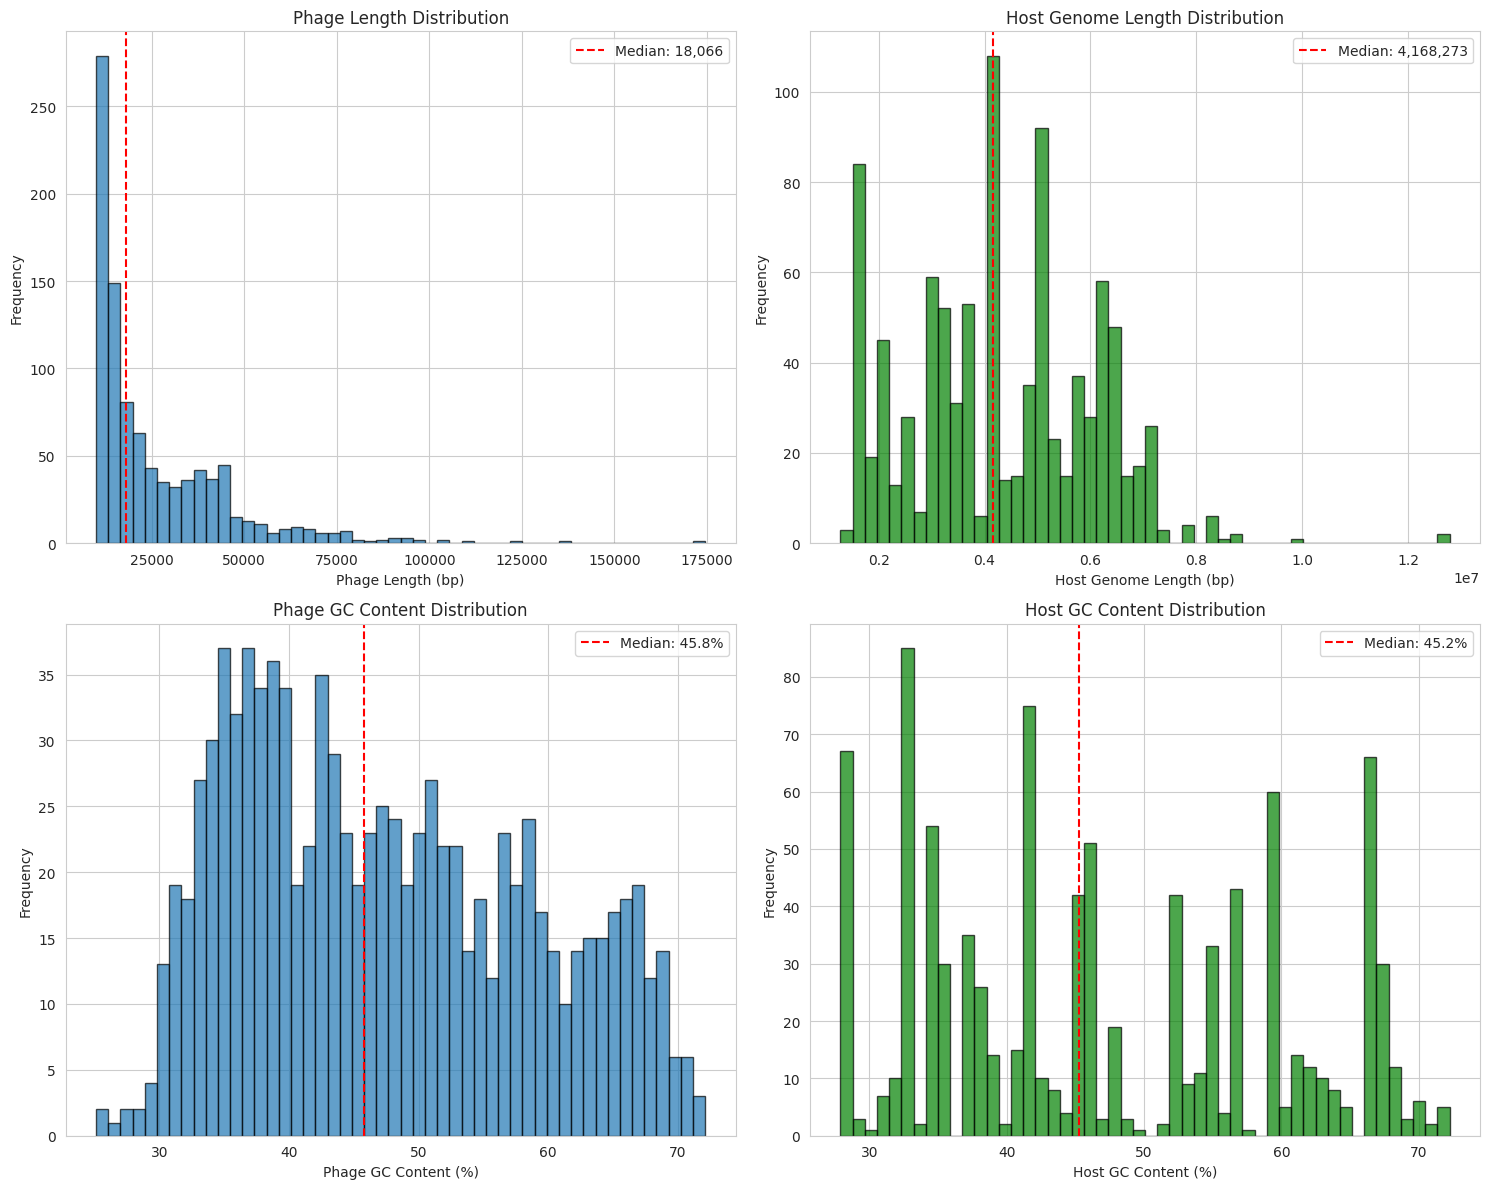

In [5]:
# Remove rows with missing values for analysis
df_clean = positive_pairs.dropna(subset=['Phage_GC', 'Host_GC', 'Phage_Length', 'Host_Length'])
print(f"Clean dataset: {len(df_clean):,} pairs (removed {len(positive_pairs) - len(df_clean):,} with missing data)")

# Plot distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Phage length distribution
axes[0, 0].hist(df_clean['Phage_Length'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Phage Length (bp)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Phage Length Distribution')
axes[0, 0].axvline(df_clean['Phage_Length'].median(), color='red', linestyle='--',
                   label=f'Median: {df_clean["Phage_Length"].median():,.0f}')
axes[0, 0].legend()

# Host genome length distribution
axes[0, 1].hist(df_clean['Host_Length'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Host Genome Length (bp)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Host Genome Length Distribution')
axes[0, 1].axvline(df_clean['Host_Length'].median(), color='red', linestyle='--',
                   label=f'Median: {df_clean["Host_Length"].median():,.0f}')
axes[0, 1].legend()

# Phage GC content
axes[1, 0].hist(df_clean['Phage_GC'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Phage GC Content (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Phage GC Content Distribution')
axes[1, 0].axvline(df_clean['Phage_GC'].median(), color='red', linestyle='--',
                   label=f'Median: {df_clean["Phage_GC"].median():.1f}%')
axes[1, 0].legend()

# Host GC content
axes[1, 1].hist(df_clean['Host_GC'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_xlabel('Host GC Content (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Host GC Content Distribution')
axes[1, 1].axvline(df_clean['Host_GC'].median(), color='red', linestyle='--',
                   label=f'Median: {df_clean["Host_GC"].median():.1f}%')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

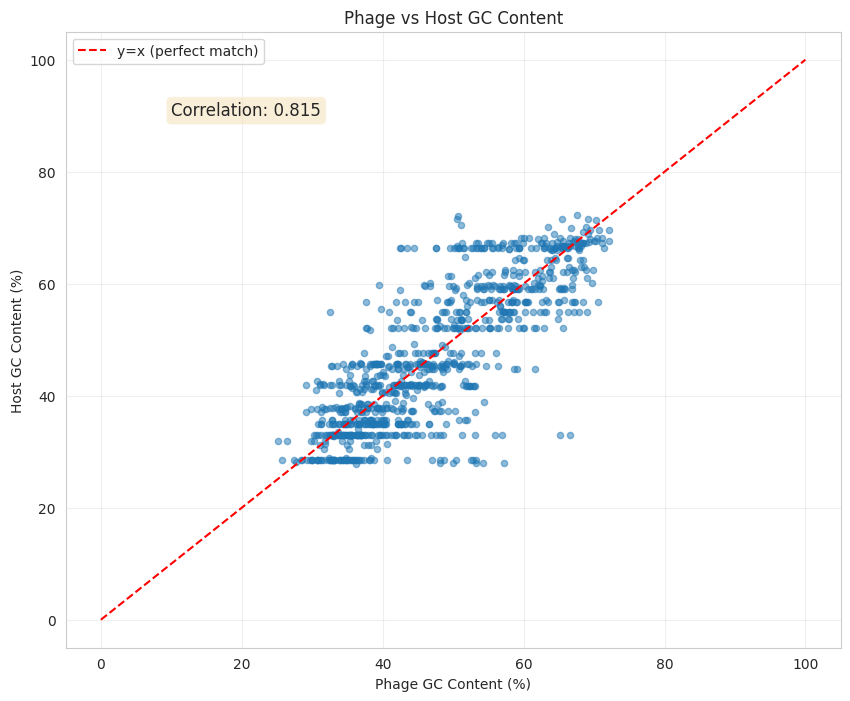

Phage-Host GC Correlation: 0.815


In [6]:
# Phage-Host GC content correlation
plt.figure(figsize=(10, 8))
plt.scatter(df_clean['Phage_GC'], df_clean['Host_GC'], alpha=0.5, s=20)
plt.xlabel('Phage GC Content (%)')
plt.ylabel('Host GC Content (%)')
plt.title('Phage vs Host GC Content')
plt.plot([0, 100], [0, 100], 'r--', label='y=x (perfect match)')
plt.legend()
plt.grid(True, alpha=0.3)

correlation = df_clean['Phage_GC'].corr(df_clean['Host_GC'])
plt.text(10, 90, f'Correlation: {correlation:.3f}', fontsize=12,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.show()
print(f"Phage-Host GC Correlation: {correlation:.3f}")

Top 10 Host Species:
Species_Name
Lawsonia intracellularis    82
Clostridioides difficile    60
Bacillus cereus             54
Pseudomonas aeruginosa      44
Bacteroides pyogenes        44
Salmonella enterica         39
Klebsiella pneumoniae       32
Enterobacter cloacae        32
Pseudomonas syringae        28
Jutongia sp. SJQ-6          24
Name: count, dtype: int64


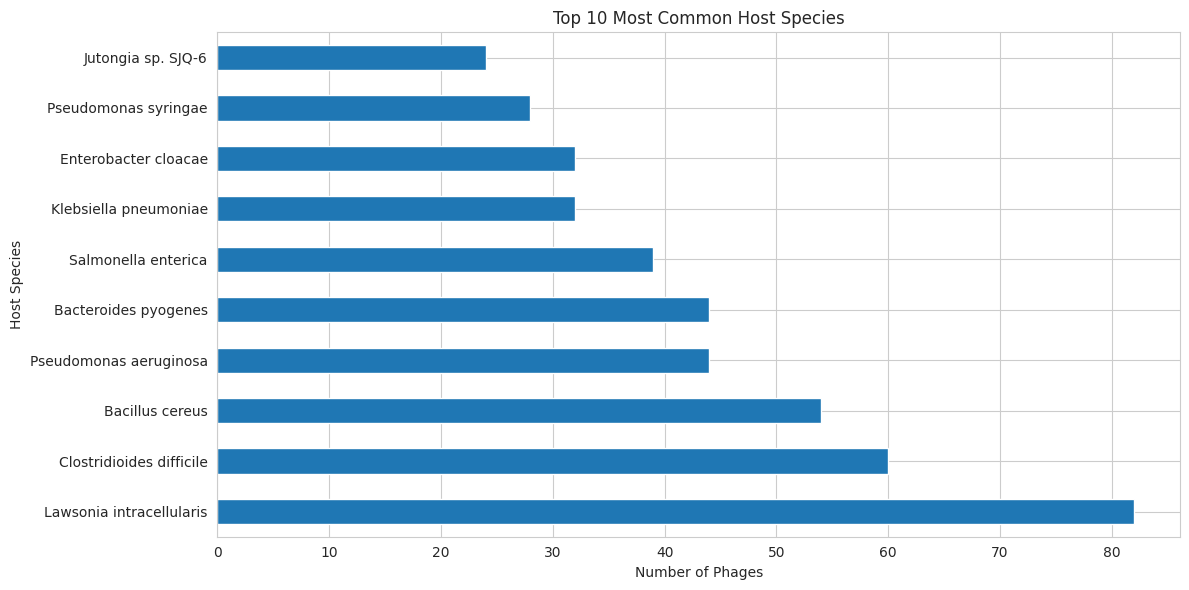

In [7]:
# Top host species in the dataset
print("Top 10 Host Species:")
host_counts = df_clean['Species_Name'].value_counts().head(10)
print(host_counts)

plt.figure(figsize=(12, 6))
host_counts.plot(kind='barh')
plt.xlabel('Number of Phages')
plt.ylabel('Host Species')
plt.title('Top 10 Most Common Host Species')
plt.tight_layout()
plt.show()

## Feature Engineering

Raw metadata columns need to be transformed into ML-ready features. Good features capture biologically meaningful relationships:

- **GC Difference**: Phages often have similar GC content to their hosts (co-evolution)
- **Length Ratio**: Phage genome is always much smaller than host — the ratio shows relative size
- **Log-transformed lengths**: Genome lengths span orders of magnitude; log-transform normalizes the distribution
- **Interaction terms**: Combined features can capture nonlinear relationships

Note: For deep learning approaches, raw sequences would be encoded as k-mers or one-hot, not as these hand-crafted features.

In [8]:
def engineer_features(df):
    """Create ML features from phage-host pair metadata."""
    features = df.copy()

    # GC content features (capture co-evolution signal)
    features['GC_Difference'] = abs(features['Phage_GC'] - features['Host_GC'])
    features['GC_Ratio'] = features['Phage_GC'] / (features['Host_GC'] + 1e-6)
    features['GC_Sum'] = features['Phage_GC'] + features['Host_GC']

    # Length features (log-transform for normality)
    features['Length_Ratio'] = features['Phage_Length'] / (features['Host_Length'] + 1)
    features['Log_Phage_Length'] = np.log10(features['Phage_Length'] + 1)
    features['Log_Host_Length'] = np.log10(features['Host_Length'] + 1)

    # Interaction features
    features['GC_x_Length_Ratio'] = features['GC_Ratio'] * features['Length_Ratio']

    return features

# Apply feature engineering to positive pairs
df_features = engineer_features(df_clean)

print("Engineered features:")
print(df_features[['GC_Difference', 'GC_Ratio', 'Length_Ratio', 'GC_x_Length_Ratio']].describe())

Engineered features:
       GC_Difference    GC_Ratio  Length_Ratio  GC_x_Length_Ratio
count     950.000000  950.000000         950.0              950.0
mean        5.420633    1.029419      0.007447           0.007864
std         4.973970    0.180009      0.006729           0.007996
min         0.004907    0.592776      0.001169           0.001048
25%         1.855398    0.923030      0.002764           0.002814
50%         4.047417    1.011131       0.00526           0.005161
75%         7.424781    1.104678      0.010153           0.010772
max        33.624431    2.038977      0.055117           0.106641


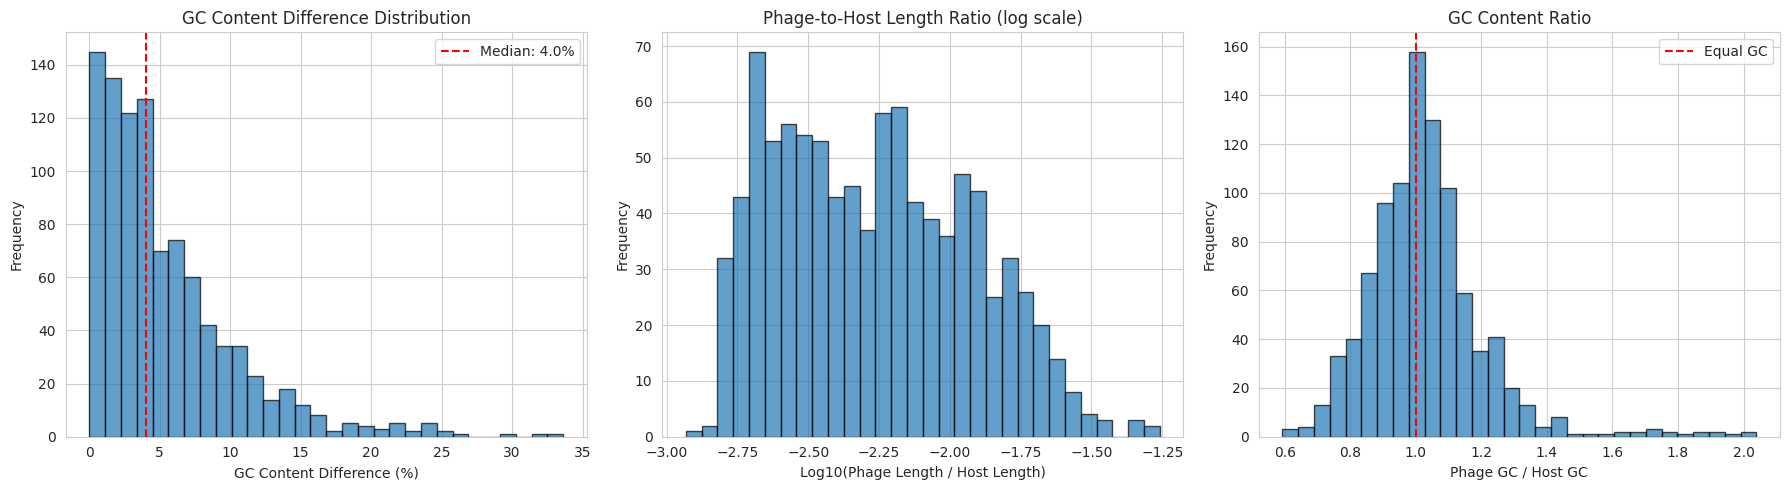

In [9]:
# Visualize key features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# GC Difference
axes[0].hist(df_features['GC_Difference'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('GC Content Difference (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('GC Content Difference Distribution')
axes[0].axvline(df_features['GC_Difference'].median(), color='red', linestyle='--',
                label=f'Median: {df_features["GC_Difference"].median():.1f}%')
axes[0].legend()

# Length Ratio (log scale)
axes[1].hist(np.log10(df_features['Length_Ratio'] + 1e-10), bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Log10(Phage Length / Host Length)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Phage-to-Host Length Ratio (log scale)')

# GC Ratio
axes[2].hist(df_features['GC_Ratio'], bins=30, edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Phage GC / Host GC')
axes[2].set_ylabel('Frequency')
axes[2].set_title('GC Content Ratio')
axes[2].axvline(1.0, color='red', linestyle='--', label='Equal GC')
axes[2].legend()

plt.tight_layout()
plt.show()

## Generate Negative Examples

For binary classification (interacts vs. does not interact), we need **negative examples** — phage-host pairs that do NOT infect each other.

**Why this is non-trivial:**
- We only know *confirmed* interactions (positives)
- The absence of a recorded interaction does NOT prove non-infection
- Randomly paired phage-host combinations are mostly non-interacting, but with noise

**PBI's `NegativeExampleGenerator` provides two strategies:**
1. **Random negatives**: Randomly pair phages with non-host bacteria (simple, may be too easy for the model)
2. **GC-based negatives**: Pair phages with hosts that have very different GC content (harder, more informative negatives)
3. **Mixed strategy**: Combine both approaches for a robust training set

The ratio parameter controls the balance: `ratio=1.0` generates 1 negative for each positive (balanced dataset).

In [10]:
# Initialize the negative example generator
neg_gen = NegativeExampleGenerator(retriever)
print("NegativeExampleGenerator initialized")

2026-02-24 18:11:41,046 - INFO - 📊 Cached 873,718 phages and 5,525 hosts
2026-02-24 18:11:41,047 - INFO - ✅ NegativeExampleGenerator initialized
2026-02-24 18:11:41,055 - INFO -    Available phages: 873,718
2026-02-24 18:11:41,056 - INFO -    Available hosts: 5,525


NegativeExampleGenerator initialized


In [11]:
# Generate random negatives (1:1 ratio with positives)
print("Generating random negative examples...")
negatives_random = neg_gen.generate_random_negatives(positive_pairs, ratio=1.0)

print(f"Generated {len(negatives_random):,} random negatives")
print(f"Label distribution: {negatives_random['Label'].value_counts().to_dict()}")

2026-02-24 18:11:41,068 - INFO - 🎲 Generating random negative examples...
2026-02-24 18:11:41,070 - INFO -    Target: 950 negatives from 950 positives
2026-02-24 18:11:41,071 - INFO -    Positive set size: 950


Generating random negative examples...


2026-02-24 18:11:43,405 - INFO -    Generated 100/950 negatives...
2026-02-24 18:11:45,500 - INFO -    Generated 200/950 negatives...
2026-02-24 18:11:47,877 - INFO -    Generated 300/950 negatives...
2026-02-24 18:11:49,979 - INFO -    Generated 400/950 negatives...
2026-02-24 18:11:52,087 - INFO -    Generated 500/950 negatives...
2026-02-24 18:11:54,188 - INFO -    Generated 600/950 negatives...
2026-02-24 18:11:56,363 - INFO -    Generated 700/950 negatives...
2026-02-24 18:11:58,458 - INFO -    Generated 800/950 negatives...
2026-02-24 18:12:00,564 - INFO -    Generated 900/950 negatives...
2026-02-24 18:12:01,623 - INFO - ✅ Generated 950 random negative pairs


Generated 950 random negatives
Label distribution: {0: 950}


In [12]:
# Generate GC-based negatives (harder negatives with large GC difference)
print("Generating GC-based negative examples...")
try:
    negatives_gc = neg_gen.generate_gc_based_negatives(
        positive_pairs,
        ratio=0.5,
        min_gc_difference=20.0
    )
    print(f"Generated {len(negatives_gc):,} GC-based negatives")
    if 'GC_Difference' in negatives_gc.columns:
        print(f"Mean GC difference in negatives: {negatives_gc['GC_Difference'].mean():.1f}%")
except Exception as e:
    print(f"GC-based negatives: {e}")

2026-02-24 18:12:01,635 - INFO - 🧬 Generating GC-based negative examples (min diff: 20.0%)...


Generating GC-based negative examples...


2026-02-24 18:12:08,156 - INFO -    Generated 100/475 negatives...
2026-02-24 18:12:08,178 - INFO -    Generated 100/475 negatives...
2026-02-24 18:12:08,200 - INFO -    Generated 100/475 negatives...
2026-02-24 18:12:08,221 - INFO -    Generated 100/475 negatives...
2026-02-24 18:12:08,243 - INFO -    Generated 100/475 negatives...
2026-02-24 18:12:14,189 - INFO -    Generated 200/475 negatives...
2026-02-24 18:12:14,211 - INFO -    Generated 200/475 negatives...
2026-02-24 18:12:14,232 - INFO -    Generated 200/475 negatives...
2026-02-24 18:12:21,423 - INFO -    Generated 300/475 negatives...
2026-02-24 18:12:21,447 - INFO -    Generated 300/475 negatives...
2026-02-24 18:12:21,469 - INFO -    Generated 300/475 negatives...
2026-02-24 18:12:21,491 - INFO -    Generated 300/475 negatives...
2026-02-24 18:12:29,906 - INFO -    Generated 400/475 negatives...
2026-02-24 18:12:29,929 - INFO -    Generated 400/475 negatives...
2026-02-24 18:12:29,951 - INFO -    Generated 400/475 negative

Generated 475 GC-based negatives
Mean GC difference in negatives: 27.6%


## Create Balanced Dataset

Combine positive and negative examples into a balanced training dataset. The `generate_balanced_dataset()` method handles this automatically with configurable strategies.

A balanced dataset (50% positive, 50% negative) is important because:
- Imbalanced datasets bias models toward the majority class
- Equal representation helps the model learn discriminative features
- Metrics like ROC-AUC are more meaningful on balanced data

In [13]:
# Generate balanced dataset using mixed strategy
print("Creating balanced dataset...")
dataset = neg_gen.generate_balanced_dataset(
    positive_pairs=positive_pairs,
    strategy='mixed',
    positive_ratio=0.5
)

print(f"\nDataset created:")
print(f"  Total samples: {len(dataset):,}")
print(f"  Positives: {(dataset['Label'] == 1).sum():,}")
print(f"  Negatives: {(dataset['Label'] == 0).sum():,}")
dataset.head()

2026-02-24 18:12:34,965 - INFO - 🔨 Generating balanced dataset (strategy: mixed, ratio: 0.5)...
2026-02-24 18:12:34,967 - INFO -    Target: 950 positives, 950 negatives
2026-02-24 18:12:34,968 - INFO - 🎲 Generating random negative examples...
2026-02-24 18:12:34,969 - INFO -    Target: 316 negatives from 950 positives
2026-02-24 18:12:34,970 - INFO -    Positive set size: 950


Creating balanced dataset...


2026-02-24 18:12:37,065 - INFO -    Generated 100/316 negatives...
2026-02-24 18:12:39,160 - INFO -    Generated 200/316 negatives...
2026-02-24 18:12:41,251 - INFO -    Generated 300/316 negatives...
2026-02-24 18:12:41,592 - INFO - ✅ Generated 316 random negative pairs
2026-02-24 18:12:41,593 - INFO - 🧬 Generating GC-based negative examples (min diff: 20.0%)...
2026-02-24 18:12:48,993 - INFO -    Generated 100/316 negatives...
2026-02-24 18:12:49,017 - INFO -    Generated 100/316 negatives...
2026-02-24 18:12:49,038 - INFO -    Generated 100/316 negatives...
2026-02-24 18:12:49,060 - INFO -    Generated 100/316 negatives...
2026-02-24 18:12:49,083 - INFO -    Generated 100/316 negatives...
2026-02-24 18:12:56,970 - INFO -    Generated 200/316 negatives...
2026-02-24 18:12:56,992 - INFO -    Generated 200/316 negatives...
2026-02-24 18:12:57,014 - INFO -    Generated 200/316 negatives...
2026-02-24 18:12:57,036 - INFO -    Generated 200/316 negatives...
2026-02-24 18:13:03,765 - INFO 


Dataset created:
  Total samples: 1,898
  Positives: 950
  Negatives: 948


,Phage_ID,Host_ID,Phage_Source,Phage_Length,Phage_GC,Phage_Taxonomy,Phage_Completeness,Phage_Lifestyle,Phage_Cluster,Phage_Subcluster,Species_Name,Host_Assembly_Level,Host_Length,Host_GC,Host_RefSeq_Category,Phage_Sequence,Host_Sequence,Label,GC_Difference
0,Station84_SUR_COMBINED_FINAL_NODE_2994_length_...,GCF_046603945_1,GOV2,16446,31.825368,Caudovirales,Low-quality,temperate,cluster_7692,subcluster_9461,Thomasclavelia ramosa,Complete Genome,3565894,31.45,na,TAGATATATAATAATTATCTGTATCAACTGAGTAACGATGTATTAA...,AAAAAAGGATACGCAGAGGTATCCGTAAATAAAAAAAGAACCGGCA...,1,NaN
1,biochar_1405,GCF_965136765_1,STV,28956,68.424506,Caudoviricetes,Low-quality,temperate,cluster_29599,subcluster_35953,Burkholderia ubonensis,Scaffold,7750385,67.29,na,CGCCAGAGTTTTGACCCGCCCCCCGGTTGCCAAATCCACCGTCCTC...,GCTCCAGTTCCGAGATCACCACCTCGATTCTCTTGCGCGCCATGAT...,1,NaN
2,MGV-GENOME-0264536,GCF_051131805_1,MGV,37775,48.905361,Caudovirales,Medium-quality,virulent,cluster_129593,subcluster_163087,Helicobacter pylori,Complete Genome,1601317,38.80,na,NaN,NaN,0,NaN
3,MGV-GENOME-0295260,GCF_052161895_1,MGV,44019,45.921080,Caudovirales,High-quality,virulent,cluster_48897,subcluster_61462,Bacteroides pyogenes,Complete Genome,3794299,45.73,na,CTGAAACTGATCCGGGTTAAAATGCATTTTTCTCTACTTAAATCTC...,TGACCAAACGTCCCAAATCTTCCAGTTCTACTCCTTTCAGATAGTT...,1,NaN
4,Station85_DCM_COMBINED_FINAL_NODE_4646_length_...,GCF_048396385_1,GOV2,11477,32.813453,Caudovirales,Low-quality,virulent,cluster_427514,subcluster_515988,Bacteroides xylanisolvens,Complete Genome,6580528,41.89,na,TTATTTAATATAAATATCTAGTAATCCCATCTAACAACAAAATTCA...,ATGATTGAATCAAATCATGTCGTACTTTGGAACCGCTGTCTCGACG...,1,NaN


Dataset with features: 1,898 samples


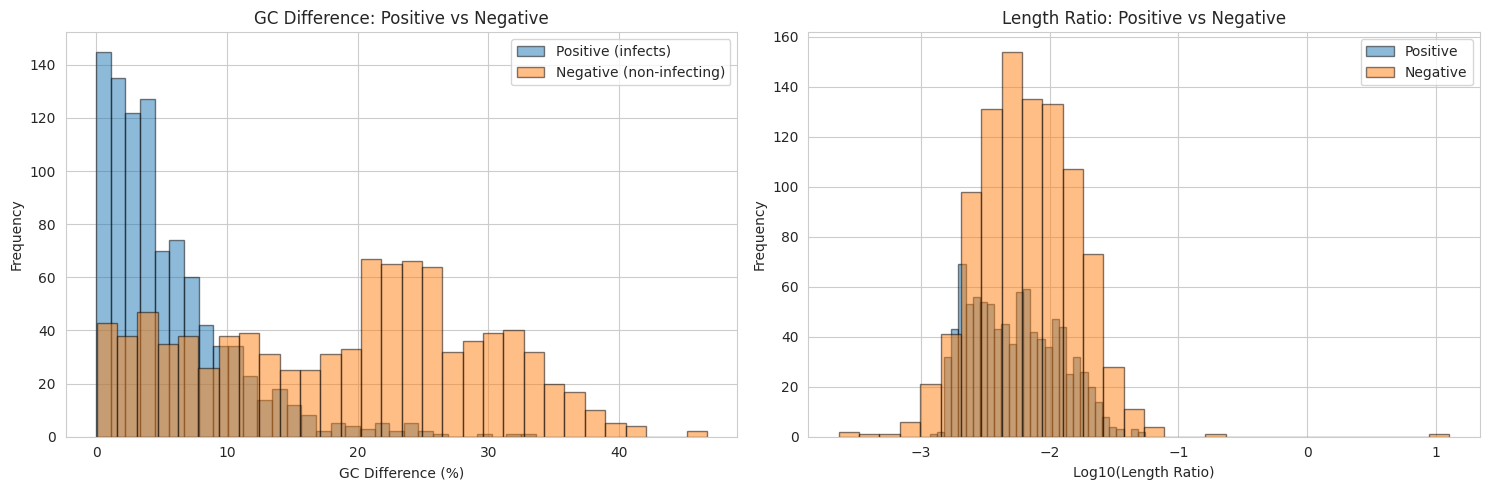

In [14]:
# Apply feature engineering to full dataset
dataset_clean = dataset.dropna(subset=['Phage_GC', 'Host_GC', 'Phage_Length', 'Host_Length'])
dataset_features = engineer_features(dataset_clean)

print(f"Dataset with features: {len(dataset_features):,} samples")

# Compare positive and negative feature distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

positive_gc = dataset_features[dataset_features['Label'] == 1]['GC_Difference']
negative_gc = dataset_features[dataset_features['Label'] == 0]['GC_Difference']

axes[0].hist(positive_gc, bins=30, alpha=0.5, label='Positive (infects)', edgecolor='black')
axes[0].hist(negative_gc, bins=30, alpha=0.5, label='Negative (non-infecting)', edgecolor='black')
axes[0].set_xlabel('GC Difference (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('GC Difference: Positive vs Negative')
axes[0].legend()

positive_ratio = dataset_features[dataset_features['Label'] == 1]['Length_Ratio']
negative_ratio = dataset_features[dataset_features['Label'] == 0]['Length_Ratio']

axes[1].hist(np.log10(positive_ratio + 1e-10), bins=30, alpha=0.5, label='Positive', edgecolor='black')
axes[1].hist(np.log10(negative_ratio + 1e-10), bins=30, alpha=0.5, label='Negative', edgecolor='black')
axes[1].set_xlabel('Log10(Length Ratio)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Length Ratio: Positive vs Negative')
axes[1].legend()

plt.tight_layout()
plt.show()

## Baseline ML Model: Random Forest

We train a Random Forest classifier as a baseline. Random Forest is a good starting point because:
- Works well with mixed feature types
- Provides feature importance scores
- Robust to outliers and correlated features
- No hyperparameter tuning needed for a baseline

After establishing this baseline, more sophisticated models can be explored (gradient boosting, neural networks, sequence-based deep learning).

In [15]:
# Define feature columns
feature_cols = [
    'Phage_Length', 'Phage_GC',
    'Host_Length', 'Host_GC',
    'GC_Difference', 'GC_Ratio', 'GC_Sum',
    'Length_Ratio', 'Log_Phage_Length', 'Log_Host_Length',
    'GC_x_Length_Ratio'
]

# Create ML-ready dataset
ml_dataset = dataset_features[feature_cols + ['Label']].dropna()
print(f"ML Dataset: {len(ml_dataset):,} samples x {len(feature_cols)} features")

# Split into train and test sets
X = ml_dataset[feature_cols]
y = ml_dataset['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")
print(f"\nClass balance (train): {y_train.value_counts().to_dict()}")

ML Dataset: 1,898 samples x 11 features
Training set: 1,518 samples
Test set: 380 samples

Class balance (train): {1: 760, 0: 758}


In [16]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features standardized")

Features standardized


In [17]:
# Train Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
print("Model trained")

Training Random Forest...
Model trained


In [18]:
# Evaluate on test set
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.3f}")

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.83      0.87       190
    Positive       0.85      0.92      0.88       190

    accuracy                           0.88       380
   macro avg       0.88      0.88      0.88       380
weighted avg       0.88      0.88      0.88       380

ROC-AUC Score: 0.954


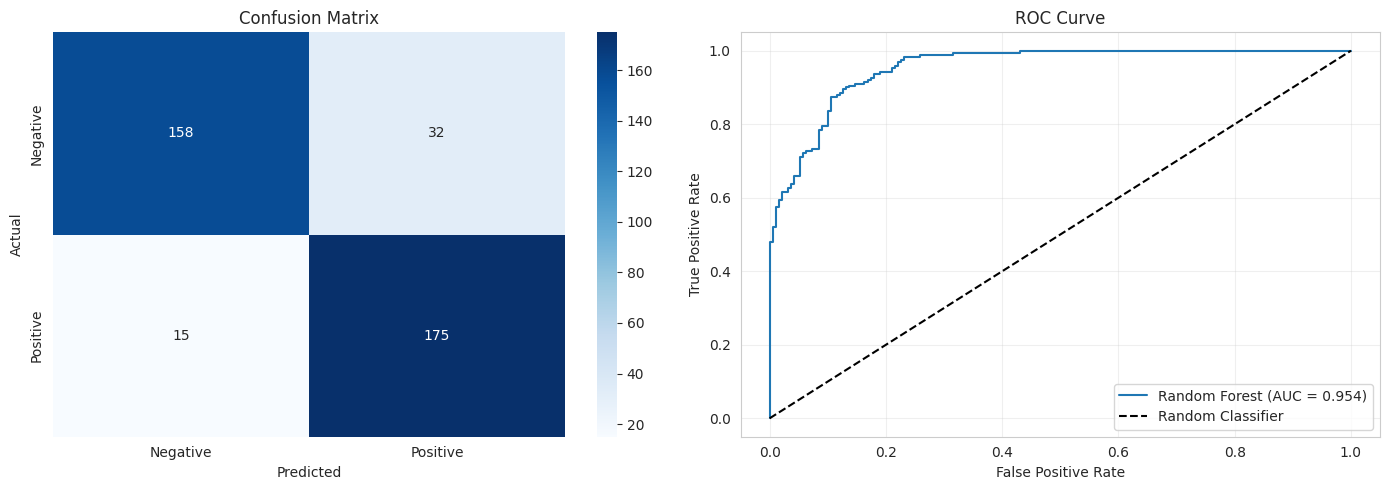

In [19]:
# Confusion Matrix and ROC Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=ax1)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

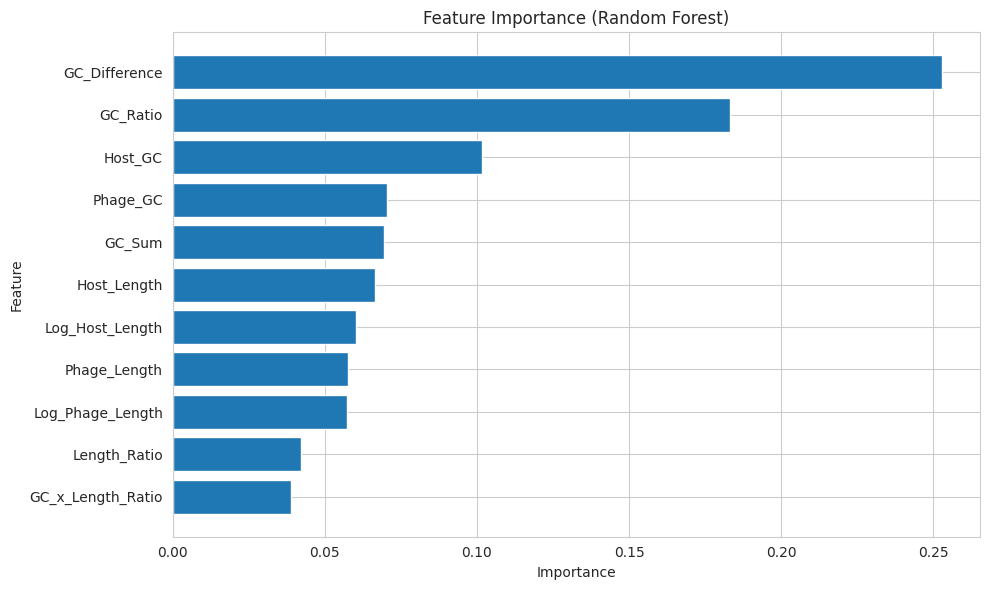


Top 5 Most Important Features:
         Feature  Importance
4  GC_Difference    0.252737
5       GC_Ratio    0.183295
3        Host_GC    0.101635
1       Phage_GC    0.070460
6         GC_Sum    0.069454


In [20]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance.head())

# Part 2: Streaming Datasets for Large-Scale ML

For large datasets (>100,000 pairs), loading everything into memory is not feasible. PBI provides streaming dataset classes that:
- Load metadata in batches from DuckDB
- Fetch sequences on-demand from FASTA files
- Keep memory usage constant regardless of dataset size
- Support PyTorch DataLoader integration

## Memory Comparison

| Approach | Memory Usage | Shuffling | Use Case |
|----------|-------------|-----------|----------|
| `get_phage_host_pairs()` | O(n) — full dataset | Yes (after load) | Small datasets (<10k) |
| `PhageHostIndexedDataset` | O(metadata) | Yes (in-memory index) | Medium datasets |
| `PhageHostStreamingDataset` | O(batch_size) | No (sequential) | Large datasets |
| `get_phage_host_pairs_iterator()` | O(batch_size) | No | Pandas workflows |

## Missing Sequence Handling

All dataset classes handle missing sequences gracefully:
> When host or phage sequences are not found in FASTA files, the dataset automatically logs a warning and skips that pair. This is expected behavior since not every phage has a downloaded host genome.

You can track which pairs are skipped using the `missing_hosts_csv` parameter.

## PhageHostStreamingDataset

Use `PhageHostStreamingDataset` when:
- Working with very large datasets (millions of pairs)
- Memory is limited
- Sequential processing is sufficient
- You don't need random access or shuffling

It fetches database records in batches, loads sequences for each batch, and yields samples one at a time.

In [21]:
# Create streaming dataset
print("Creating streaming dataset...")
streaming_dataset = retriever.create_streaming_dataset(
    where_clause=None,  # No filter - get all phage-host pairs
    batch_size=1000    # Fetch 1000 records at a time from the database
)

print("Created streaming dataset")
print("  Database batch size: 1000 records")
print("  Memory usage: constant (only 1 batch in memory at a time)")

# Iterate through samples
print("\nStreaming first 5 samples:")
for i, sample in enumerate(streaming_dataset):
    if i >= 5:
        break
    print(f"  Sample {i+1}:")
    print(f"    Phage: {sample['Phage_ID'][:40]}")
    print(f"    Host: {sample.get('Species_Name', 'N/A')[:40]}")
    print(f"    Phage seq length: {len(sample.get('Phage_Sequence', '')):,} bp")
    print(f"    Host seq length: {len(sample.get('Host_Sequence', '')):,} bp")

print("\nStreaming completed")

2026-02-24 18:13:14,985 - INFO - Using host mapping with 5525 hosts


Creating streaming dataset...
Created streaming dataset
  Database batch size: 1000 records
  Memory usage: constant (only 1 batch in memory at a time)

Streaming first 5 samples:


2026-02-24 18:13:39,629 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1


  Sample 1:
    Phage: Station23_DCM_ALL_assembly_NODE_1538_len
    Host: Streptococcus agalactiae
    Phage seq length: 13,963 bp
    Host seq length: 2,034,123 bp
  Sample 2:
    Phage: Station23_DCM_ALL_assembly_NODE_1735_len
    Host: Vibrio parahaemolyticus
    Phage seq length: 13,081 bp
    Host seq length: 3,326,935 bp
  Sample 3:
    Phage: Station23_DCM_ALL_assembly_NODE_2475_len
    Host: Clostridioides difficile
    Phage seq length: 10,682 bp
    Host seq length: 4,122,960 bp
  Sample 4:
    Phage: Station25_DCM_ALL_assembly_NODE_1185_len
    Host: Streptococcus pyogenes
    Phage seq length: 19,508 bp
    Host seq length: 1,897,626 bp
  Sample 5:
    Phage: Station25_DCM_ALL_assembly_NODE_1673_len
    Host: Segatella copri
    Phage seq length: 15,681 bp
    Host seq length: 3,992,021 bp

Streaming completed


In [22]:
# With PyTorch DataLoader
if TORCH_AVAILABLE:
    dataloader = DataLoader(
        streaming_dataset,
        batch_size=32,
        num_workers=0,  # Use 0 for notebooks; >0 in production
        collate_fn=phage_host_collate_fn
    )

    print("Processing streaming batches with DataLoader:")
    for i, batch in enumerate(dataloader):
        if i >= 3:
            break
        print(f"  Batch {i+1}: {len(batch['Phage_ID'])} samples")
        print(f"    First Phage: {batch['Phage_ID'][0][:40]}")

    print("PyTorch streaming iteration complete")
else:
    print("PyTorch not available - using manual iteration (shown above)")

Processing streaming batches with DataLoader:


2026-02-24 18:13:47,122 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1
2026-02-24 18:13:47,512 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1
2026-02-24 18:13:48,017 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_978422695_1


  Batch 1: 32 samples
    First Phage: Station23_DCM_ALL_assembly_NODE_1538_len


2026-02-24 18:13:48,404 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1


  Batch 2: 32 samples
    First Phage: Station33_SUR_ALL_assembly_NODE_1826_len


2026-02-24 18:13:48,740 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_978422695_1
2026-02-24 18:13:48,751 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_978422695_1
2026-02-24 18:13:48,806 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1
2026-02-24 18:13:48,808 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_978422695_1


  Batch 3: 32 samples
    First Phage: Station34_DCM_ALL_assembly_NODE_2285_len


2026-02-24 18:13:48,952 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1


PyTorch streaming iteration complete


## PhageHostIndexedDataset with Shuffling

Use `PhageHostIndexedDataset` when:
- Dataset fits in memory (metadata cached)
- You need shuffling for better training convergence
- You want multi-worker data loading
- Random access is needed (e.g., curriculum learning)

It pre-loads all metadata into a list (fast, compact), then fetches sequences on-demand by index.

In [23]:
# Create indexed dataset (supports random access and shuffling)
print("Creating indexed dataset...")
indexed_dataset = retriever.create_indexed_dataset(
    where_clause=None  # No filter
)

print(f"Created indexed dataset")
print(f"  Total samples: {len(indexed_dataset):,}")
print(f"  Supports random access: Yes")
print(f"  Metadata cached in memory: Yes")

if len(indexed_dataset) > 0:
    # Direct index access
    sample_0 = indexed_dataset[0]
    print(f"\nSample 0:")
    print(f"  Phage_ID: {sample_0['Phage_ID'][:50]}")
    print(f"  Species_Name: {sample_0.get('Species_Name', 'N/A')[:50]}")
    print(f"  Phage seq length: {len(sample_0.get('Phage_Sequence', '')):,} bp")

2026-02-24 18:13:49,944 - INFO - Using host mapping with 5525 hosts


Creating indexed dataset...


2026-02-24 18:14:01,760 - INFO - Loaded metadata for 782089 phage-host pairs


Created indexed dataset
  Total samples: 782,089
  Supports random access: Yes
  Metadata cached in memory: Yes

Sample 0:
  Phage_ID: Station23_DCM_ALL_assembly_NODE_1735_length_13081_
  Species_Name: Vibrio parahaemolyticus
  Phage seq length: 13,081 bp


In [24]:
# With PyTorch DataLoader and shuffling
if TORCH_AVAILABLE and len(indexed_dataset) > 0:
    shuffled_loader = DataLoader(
        indexed_dataset,
        batch_size=32,
        shuffle=True,  # Randomly shuffle samples each epoch
        num_workers=0,
        collate_fn=phage_host_collate_fn
    )

    print("Shuffled DataLoader iteration:")
    for i, batch in enumerate(shuffled_loader):
        if i >= 3:
            break
        print(f"  Batch {i+1}: {len(batch['Phage_ID'])} samples")
        print(f"    Sample Phage IDs: {[p[:20] for p in batch['Phage_ID'][:3]]}")

    print("\nNote: Each epoch will see samples in different order (shuffled)")
elif len(indexed_dataset) == 0:
    print("Dataset is empty - check database content")
else:
    print("PyTorch not available - IndexedDataset still supports direct index access")

2026-02-24 18:14:07,833 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1


Shuffled DataLoader iteration:


2026-02-24 18:14:08,076 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1
2026-02-24 18:14:08,188 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1


  Batch 1: 32 samples
    Sample Phage IDs: ['uvig_132391', 'IMGVR_UViG_274089210', 'uvig_284747']


2026-02-24 18:14:08,482 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1
2026-02-24 18:14:08,572 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1


  Batch 2: 32 samples
    Sample Phage IDs: ['Station124_SUR_ALL_a', 'Ly_CA6_ion_torrent_N', 'SRS147386_a1_ct36206']


2026-02-24 18:14:08,867 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1
2026-02-24 18:14:08,945 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1
2026-02-24 18:14:08,993 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1


  Batch 3: 32 samples
    Sample Phage IDs: ['IMGVR_UViG_330002911', 'Han_2018_ERR1398108_', 'biochar_4978']


2026-02-24 18:14:09,182 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1
2026-02-24 18:14:09,206 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_978422695_1



Note: Each epoch will see samples in different order (shuffled)


## Simple Batch Iterator (Non-PyTorch)

Use `get_phage_host_pairs_iterator()` when:
- You don't need PyTorch
- You want DataFrame batches for pandas-based workflows
- Simple batch processing is sufficient
- Exporting data to files incrementally

This yields pandas DataFrames, making it easy to integrate with sklearn, pandas operations, or custom code.

In [25]:
# Create batch iterator
print("Batch iterator (non-PyTorch):")
print("-" * 60)

batch_iterator = retriever.get_phage_host_pairs_iterator(
    where_clause="p.Length > 10000",  # Filter for larger phages
    batch_size=500
)

max_batches = 3
total_processed = 0

for i, batch_df in enumerate(batch_iterator):
    if i >= max_batches:
        break

    total_processed += len(batch_df)
    avg_phage_gc = batch_df['Phage_GC'].mean()
    avg_host_gc = batch_df['Host_GC'].mean()

    print(f"Batch {i+1}: {len(batch_df)} pairs")
    print(f"  Avg Phage GC: {avg_phage_gc:.2f}%")
    print(f"  Avg Host GC: {avg_host_gc:.2f}%")
    print(f"  Columns: {list(batch_df.columns[:5])}...")

print(f"\nTotal processed: {total_processed} pairs")
print("\nYou can process each batch independently:")
print("  - Apply feature engineering")
print("  - Train on batch (online learning)")
print("  - Write batch to file")

2026-02-24 18:14:09,228 - INFO - 🔍 Starting batch iteration with batch_size=500


Batch iterator (non-PyTorch):
------------------------------------------------------------


2026-02-24 18:14:11,328 - INFO - 📦 Processing batch 1 (750534 pairs)
2026-02-24 18:14:16,009 - WARNING - ⚠️  Phage sequence not found for ID: BK000583.1
2026-02-24 18:23:13,694 - WARNING - ⚠️  Host sequence not found for ID: GCF_978422695_1
2026-02-24 18:23:13,847 - WARNING - ⚠️  Host sequence not found for ID: GCF_979243125_1
2026-02-24 18:23:20,122 - WARNING - ⚠️  Host sequence not found for ID: GCF_978632265_1
2026-02-24 18:23:22,499 - WARNING - ⚠️  Host sequence not found for ID: GCF_055135105_1
2026-02-24 18:23:24,366 - WARNING - ⚠️  Host sequence not found for ID: GCF_979902625_1
2026-02-24 18:23:24,382 - WARNING - ⚠️  Host sequence not found for ID: GCA_002491635_1
2026-02-24 18:23:24,678 - WARNING - ⚠️  Host sequence not found for ID: GCF_979932065_1
2026-02-24 18:23:31,985 - WARNING - ⚠️  Host sequence not found for ID: GCA_002358615_1
2026-02-24 18:23:33,989 - WARNING - ⚠️  Host sequence not found for ID: GCF_979257775_1
2026-02-24 18:24:05,202 - WARNING - ⚠️  Host sequence n

Batch 1: 750534 pairs
  Avg Phage GC: 44.19%
  Avg Host GC: 44.72%
  Columns: ['Phage_ID', 'Host_ID', 'Phage_Source', 'Phage_Length', 'Phage_GC']...

Total processed: 750534 pairs

You can process each batch independently:
  - Apply feature engineering
  - Train on batch (online learning)
  - Write batch to file


## Custom Transforms

Both streaming and indexed datasets support a `transform` function applied to each sample before it's returned. This is ideal for:
- Sequence encoding (one-hot, k-mers, dinucleotide frequencies)
- Feature extraction
- Data augmentation
- Normalization and preprocessing

The transform receives a dictionary with all metadata and sequence fields.

In [26]:
# Define a custom transform
def genomic_feature_transform(sample):
    """
    Transform that computes additional genomic features from sequences.

    In production, this could include:
    - K-mer frequency vectors
    - Codon usage tables
    - CRISPR spacer matches
    - Protein domain counts
    """
    phage_seq = sample.get('Phage_Sequence', '')
    host_seq = sample.get('Host_Sequence', '')

    # Length features from actual sequences (may differ from metadata)
    sample['phage_seq_length'] = len(phage_seq)
    sample['host_seq_length'] = len(host_seq)
    sample['length_ratio_computed'] = len(phage_seq) / max(len(host_seq), 1)

    # GC content computed from sequence
    if phage_seq:
        upper = phage_seq.upper()
        gc = (upper.count('G') + upper.count('C')) / max(len(phage_seq), 1)
        sample['phage_gc_computed'] = gc * 100
    else:
        sample['phage_gc_computed'] = None

    # Length category for stratification
    sample['phage_size_category'] = (
        'jumbo' if len(phage_seq) > 200000
        else 'large' if len(phage_seq) > 50000
        else 'medium' if len(phage_seq) > 10000
        else 'small'
    )

    return sample

# Create dataset with transform
transformed_dataset = retriever.create_indexed_dataset(
    where_clause="LIMIT 50",
    transform=genomic_feature_transform
)

print(f"Created dataset with custom transform: {len(transformed_dataset)} samples")

if len(transformed_dataset) > 0:
    sample = transformed_dataset[0]
    print("\nTransformed sample fields (non-sequence):")
    for key, val in sorted(sample.items()):
        if key not in ('Phage_Sequence', 'Host_Sequence'):
            print(f"  {key}: {val}")
    print("\nTransform applied successfully")

2026-02-24 18:25:03,393 - INFO - Using host mapping with 5525 hosts
2026-02-24 18:25:03,856 - INFO - Loaded metadata for 50 phage-host pairs


Created dataset with custom transform: 50 samples

Transformed sample fields (non-sequence):
  Host_Assembly_Level: Chromosome
  Host_GC: 45.32
  Host_ID: GCF_054898485_1
  Host_Length: 5253374
  Host_RefSeq_Category: na
  Phage_Cluster: cluster_482598
  Phage_Completeness: Low-quality
  Phage_GC: 41.3347603394236
  Phage_ID: Station23_DCM_ALL_assembly_NODE_1735_length_13081_cov_2.513358
  Phage_Length: 13081
  Phage_Lifestyle: virulent
  Phage_Source: GOV2
  Phage_Subcluster: subcluster_580904
  Phage_Taxonomy: Caudovirales
  Species_Name: Vibrio parahaemolyticus
  host_seq_length: 3326935
  length_ratio_computed: 0.003931847180663283
  phage_gc_computed: 41.334760339423596
  phage_seq_length: 13081
  phage_size_category: medium

Transform applied successfully


## Train/Test Split Strategy

For ML evaluation, we need separate train and test sets that don't leak information. With streaming datasets, use WHERE clauses to create non-overlapping splits:

**Strategy options:**
1. **LIMIT/OFFSET**: Simple sequential split (easy, but may have temporal bias)
2. **Source-based**: Train on one database, test on another (tests generalization)
3. **Taxonomy-based**: Train on certain phage families, test on others
4. **Host-based**: Train on certain host species, test on unseen hosts

The last two strategies (source/taxonomy-based) are the most rigorous for biological generalization.

In [27]:
# Create train/test split using LIMIT/OFFSET
print("Creating train/test datasets:")

# Training set: first 5000 pairs
train_dataset = retriever.create_streaming_dataset(
    where_clause="LIMIT 5000",
    batch_size=1000
)
print("Training dataset: first 5000 pairs (streaming)")

# Test set: next 1000 pairs (no overlap with training)
test_dataset = retriever.create_indexed_dataset(
    where_clause="LIMIT 1000 OFFSET 5000"
)
print(f"Test dataset: next 1000 pairs (indexed), size={len(test_dataset)}")

if TORCH_AVAILABLE:
    train_loader = DataLoader(
        train_dataset, batch_size=32, num_workers=0, collate_fn=phage_host_collate_fn
    )
    test_loader = DataLoader(
        test_dataset, batch_size=32, shuffle=False, num_workers=0, collate_fn=phage_host_collate_fn
    )
    print("\nDataLoaders created")
    print("  Train: streaming, sequential")
    print("  Test: indexed, sequential (no shuffle for evaluation)")
    print("\nIn a training loop:")
    print("  for epoch in range(num_epochs):")
    print("    model.train()")
    print("    for batch in train_loader: ...")
    print("    model.eval()")
    print("    for batch in test_loader: ...")
else:
    print("\nWithout PyTorch, iterate directly:")
    print("  for sample in train_dataset: ...")
    print("  for i in range(len(test_dataset)): sample = test_dataset[i]")

print("\nAlternative splits:")
print("  train = create_streaming_dataset(where_clause=\"p.Source_DB = 'INPHARED'\")")

2026-02-24 18:25:09,807 - INFO - Using host mapping with 5525 hosts
2026-02-24 18:25:09,812 - INFO - Using host mapping with 5525 hosts


Creating train/test datasets:
Training dataset: first 5000 pairs (streaming)


2026-02-24 18:25:10,332 - INFO - Loaded metadata for 1000 phage-host pairs


Test dataset: next 1000 pairs (indexed), size=1000

DataLoaders created
  Train: streaming, sequential
  Test: indexed, sequential (no shuffle for evaluation)

In a training loop:
  for epoch in range(num_epochs):
    model.train()
    for batch in train_loader: ...
    model.eval()
    for batch in test_loader: ...

Alternative splits:
  train = create_streaming_dataset(where_clause="p.Source_DB = 'INPHARED'")


## Tracking Missing Sequences

The datasets automatically skip pairs where sequences cannot be found, logging a warning for each. You can capture these in a CSV file for analysis and debugging.

Common reasons for missing sequences:
- **Host genome not downloaded**: The pipeline didn't download this host genome
- **FASTA file not found**: The file exists in the database but not on disk
- **Sequence not in index**: The FASTA file exists but doesn't contain this accession
- **Corrupted index**: The `.fai` index is out of date

Note: This is **expected behavior** — the dataset logs and skips, then continues normally.

In [28]:
# Track missing sequences
import os, tempfile

missing_csv = Path(tempfile.mktemp(suffix='_missing_hosts.csv'))

print("Creating dataset with missing host tracking...")
dataset_tracked = retriever.create_streaming_dataset(
    where_clause=None,
    batch_size=1000,
    missing_hosts_csv=str(missing_csv)
)

# Process a sample of the data
print("Processing 100 samples...")
processed = 0
for sample in dataset_tracked:
    processed += 1
    if processed >= 100:
        break

print(f"Processed {processed} samples")

# Check missing hosts CSV
if missing_csv.exists():
    missing_df = pd.read_csv(missing_csv)
    print(f"\nMissing sequences logged: {len(missing_df)}")
    if len(missing_df) > 0:
        print("\nFailure reasons breakdown:")
        print(missing_df['Failure_Reason'].value_counts())
        print("\nSample missing records:")
        print(missing_df[['Phage_ID', 'Host_ID', 'Failure_Reason']].head())
    os.unlink(str(missing_csv))
else:
    print("\nAll sequences found - no missing data (great!)")

2026-02-24 18:25:10,355 - INFO - Using host mapping with 5525 hosts


Creating dataset with missing host tracking...
Processing 100 samples...


2026-02-24 18:25:17,054 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1
2026-02-24 18:25:17,901 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1
2026-02-24 18:25:18,393 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1
2026-02-24 18:25:18,408 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_978422695_1
2026-02-24 18:25:18,529 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1
2026-02-24 18:25:18,588 - WARNING - ⚠️  Host genome not in mapping (not downloaded/available for this host): GCF_979243125_1


Processed 100 samples

All sequences found - no missing data (great!)


## Summary and Best Practices

### When to Use Each Approach

**DataFrame approach (`get_phage_host_pairs()`):**
- Best for: Exploration, feature engineering, small datasets (<10k pairs)
- Pros: All pandas operations available, easy to inspect
- Cons: All data in memory at once

**PhageHostIndexedDataset:**
- Best for: Medium datasets with shuffling needs (<100k pairs)
- Pros: Random access, PyTorch-compatible, shuffling
- Cons: Metadata must fit in RAM

**PhageHostStreamingDataset:**
- Best for: Large-scale training (millions of pairs)
- Pros: Constant memory, scales to any size
- Cons: No shuffling, sequential only

**Batch Iterator:**
- Best for: Pandas-based workflows, incremental file writing
- Pros: Simple, no PyTorch needed
- Cons: No shuffling, sequential

### Performance Tips
- Use `WHERE` clauses to filter at the database level (much faster than post-filtering)
- Set `batch_size` based on available RAM (larger = fewer DB queries but more memory)
- Use `num_workers > 0` in production DataLoaders (not in Jupyter notebooks)
- Cache the indexed dataset metadata; don't recreate it every epoch

### Data Quality Best Practices
- Filter to complete/high-quality genomes for reliable sequence features
- Always generate negative examples for binary classification
- Use source-based or taxonomy-based train/test splits for biological generalization
- Track missing sequences to understand data coverage

### Advanced ML Directions
- **K-mer features**: Represent sequences as k-mer frequency vectors
- **Language models**: DNA-BERT, Nucleotide Transformer for sequence embeddings
- **Graph neural networks**: Model phage-host interaction networks
- **Multi-task learning**: Predict host range + lifestyle simultaneously

In [29]:
# Cleanup
retriever.close()
print("Database connection closed")

2026-02-24 18:25:19,650 - INFO - 🔒 Database connection closed


Database connection closed
